# Uncertainty-Aware IR Drop Prediction in VLSI Physical Design
**ECE 228**


In [ ]:
%matplotlib inline
import os, sys, copy, warnings
warnings.filterwarnings('ignore')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
from scipy.stats import spearmanr
from sklearn.metrics import (roc_auc_score, f1_score, roc_curve,
                             precision_recall_curve, auc as sk_auc)
from typing import Dict, List, Optional, Tuple
from IPython.display import Image, display as ipy_display
print("donedljgfdjf")

In [ ]:
class Config:
    data_root = './data/processed'
    ann_file = './data/processed/train.csv'
    save_dir = './checkpoints'
    fig_dir = './figures'

    # data
    in_channels = 3        # power_i, power_s, power_all
    out_channels = 1
    img_size = 128      # on-the-fly resize from 256×256

    # training
    batch_size = 16
    lr = 1e-3
    weight_decay = 1e-5
    epochs = 50
    num_workers = 0 

    # ensemble
    ensemble_size = 5
    base_seed = 42      # member m uses base_seed + m*1000

    # conformal prediction
    calib_fraction = 0.5
    alpha_levels = [0.05, 0.10, 0.20]   # 95%, 90%, 80% nominal coverage

    # hotspot
    hotspot_percentile = 95

    @staticmethod
    def device():     #@sidharth check if this will work on your 'maCbOOk'
        if torch.backends.mps.is_available(): return torch.device('mps')
        if torch.cuda.is_available():         return torch.device('cuda')
        return torch.device('cpu')
        #print(torch.__version__)

Device: mps


In [ ]:
class CircuitNetIRDropDataset(Dataset):
    def __init__(self, ann_file, data_root, augment=False, img_size=None):
        self.data_root = data_root
        self.augment   = augment
        self.img_size  = img_size
        self.samples   = []
        with open(ann_file) as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('#'):
                    continue
                feat_rel, label_rel = line.split(',')
                self.samples.append((
                    os.path.join(data_root, feat_rel),
                    os.path.join(data_root, label_rel),
                ))
        print(f'Loaded {len(self.samples)} samples from {ann_file}')

    def __len__(self): return len(self.samples)

    def _resize(self, feat, lbl):
        if self.img_size is None or feat.shape[-1] == self.img_size:
            return feat, lbl
        s    = self.img_size
        feat = F.interpolate(feat.unsqueeze(0), (s, s), mode='bilinear',
                             align_corners=False).squeeze(0)
        lbl  = F.interpolate(lbl.unsqueeze(0),  (s, s), mode='bilinear',
                             align_corners=False).squeeze(0)
        return feat, lbl

    def __getitem__(self, idx):
        feat_path, label_path = self.samples[idx]
        feature = np.load(feat_path).astype(np.float32)    # (H, W, C)
        label   = np.load(label_path).astype(np.float32)   # (H, W) or (H, W, 1)
        if label.ndim == 2:
            label = label[:, :, np.newaxis]
        if self.augment:
            if np.random.rand() > 0.5:
                feature = np.flip(feature, 0).copy()
                label   = np.flip(label,   0).copy()
            if np.random.rand() > 0.5:
                feature = np.flip(feature, 1).copy()
                label   = np.flip(label,   1).copy()
            k = np.random.randint(4)
            if k > 0:
                feature = np.rot90(feature, k, (0, 1)).copy()
                label   = np.rot90(label,   k, (0, 1)).copy()
        feature = torch.from_numpy(feature.transpose(2, 0, 1))
        label   = torch.from_numpy(label.transpose(2, 0, 1))
        return self._resize(feature, label)


def build_dataloaders(cfg):
    """Return dict with keys: train, val, calib, test."""
    full_ds = CircuitNetIRDropDataset(cfg.ann_file, cfg.data_root,
                                      img_size=cfg.img_size)
    n       = len(full_ds)
    n_train = int(0.70 * n)
    n_val   = int(0.15 * n)
    n_test  = n - n_train - n_val

    train_ds, val_ds, test_ds = random_split(
        full_ds, [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(cfg.base_seed)
    )
    train_aug         = CircuitNetIRDropDataset(cfg.ann_file, cfg.data_root,augment=True, img_size=cfg.img_size)
    train_aug.samples = [full_ds.samples[i] for i in train_ds.indices]
    #print("gsjbsdfkjhbdf kjsg here"))

    n_calib    = int(cfg.calib_fraction * n_val)
    n_val_eval = n_val - n_calib
    val_eval_ds, calib_ds = random_split(
        val_ds, [n_val_eval, n_calib],
        generator=torch.Generator().manual_seed(cfg.base_seed + 1)
    )
    kw = dict(num_workers=cfg.num_workers,
              pin_memory=torch.cuda.is_available())
    loaders = {
        'train': DataLoader(train_aug,   batch_size=cfg.batch_size, shuffle=True,  **kw),
        'val':   DataLoader(val_eval_ds, batch_size=cfg.batch_size, shuffle=False, **kw),
        'calib': DataLoader(calib_ds,    batch_size=cfg.batch_size, shuffle=False, **kw),
        'test':  DataLoader(test_ds,     batch_size=cfg.batch_size, shuffle=False, **kw),
    }
    print(f'Splits — train:{len(train_aug)}  val:{n_val_eval}  calib:{n_calib}  test:{n_test}')
    return loaders


In [ ]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.block(x)


class UpConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Sequential(
            nn.ConvTranspose2d(in_ch, out_ch, kernel_size=4, stride=2, padding=1),
            nn.InstanceNorm2d(out_ch, affine=True),
            nn.LeakyReLU(0.2, inplace=True),
        )
    def forward(self, x): return self.up(x)


class IRDropUNet(nn.Module):
    """out_ch=1 for regression (Stages 1 & 2); out_ch=3 for CQR (q_lo, median, q_hi)."""
    def __init__(self, in_ch=3, out_ch=1):
        super().__init__()
        self.enc1, self.pool1 = ConvBlock(in_ch,  32),  nn.MaxPool2d(2)
        self.enc2, self.pool2 = ConvBlock(32,      64),  nn.MaxPool2d(2)
        self.enc3, self.pool3 = ConvBlock(64,     128),  nn.MaxPool2d(2)
        self.enc4, self.pool4 = ConvBlock(128,    256),  nn.MaxPool2d(2)
        self.bottleneck       = ConvBlock(256,    512)
        self.up4, self.dec4   = UpConv(512, 256), ConvBlock(512, 256)
        self.up3, self.dec3   = UpConv(256, 128), ConvBlock(256, 128)
        self.up2, self.dec2   = UpConv(128,  64), ConvBlock(128,  64)
        self.up1, self.dec1   = UpConv( 64,  32), ConvBlock( 64,  32)
        self.out_conv         = nn.Sequential(nn.Conv2d(32, out_ch, 1), nn.Sigmoid())

    def forward(self, x):  #check ths once i think somethings wrong
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bottleneck(self.pool4(e4))
        d4 = self.dec4(torch.cat([self.up4(b),  e4], dim=1))
        d3 = self.dec3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out_conv(d1)


In [ ]:
def compute_nrmse(pred, target):
    rmse = np.sqrt(((pred - target) ** 2).mean())
    r    = target.max() - target.min()
    return float(rmse / r) if r > 1e-10 else 0.0


def compute_ssim(pred, target, c1=1e-4, c2=9e-4):
    mu_p, mu_t   = pred.mean(), target.mean()
    sig_p, sig_t = pred.var(), target.var()
    sig_pt       = ((pred - mu_p) * (target - mu_t)).mean()
    return float(
        (2 * mu_p * mu_t + c1) * (2 * sig_pt + c2)
        / ((mu_p**2 + mu_t**2 + c1) * (sig_p + sig_t + c2))
    )


def compute_hotspot_metrics(pred, target, label_thresh, pred_thresh=None):
    tgt_bin = (target.ravel() >= label_thresh).astype(np.float32)
    p_flat  = pred.ravel()
    if tgt_bin.sum() == 0 or tgt_bin.sum() == len(tgt_bin):
        return {'roc_auc': float('nan'), 'pr_auc': float('nan'), 'f1': float('nan')}
    roc_auc       = roc_auc_score(tgt_bin, p_flat)
    prec, rec, _  = precision_recall_curve(tgt_bin, p_flat)
    pr_auc        = sk_auc(rec, prec)
    t             = pred_thresh if pred_thresh is not None else label_thresh
    f1_val        = f1_score(tgt_bin, (p_flat >= t).astype(np.float32), zero_division=0)
    return {'roc_auc': roc_auc, 'pr_auc': pr_auc, 'f1': f1_val}


@torch.no_grad()
def evaluate_model(model, loader, hotspot_thresh=None, pred_thresh=None, device=None):
    if device is None: device = Config.device()
    model.eval()
    nrmses, ssims, all_p, all_t = [], [], [], []
    for features, labels in loader:
        preds   = model(features.to(device)).cpu().numpy()
        targets = labels.numpy()
        for i in range(preds.shape[0]):
            nrmses.append(compute_nrmse(preds[i, 0], targets[i, 0]))
            ssims.append( compute_ssim( preds[i, 0], targets[i, 0]))
            all_p.append(preds[i, 0]); all_t.append(targets[i, 0])
    res = {'nrmse': float(np.mean(nrmses)), 'ssim': float(np.mean(ssims))}
    if hotspot_thresh is not None:
        p = np.concatenate([x.ravel() for x in all_p])
        t = np.concatenate([x.ravel() for x in all_t])
        res.update(compute_hotspot_metrics(p, t, hotspot_thresh, pred_thresh))
    return res


In [ ]:
def compute_hotspot_threshold(loaders, percentile=95):
    all_labels = []
    for _, labels in loaders['train']:
        all_labels.append(labels.numpy().ravel())
    return float(np.percentile(np.concatenate(all_labels), percentile))
#clean this up

def train_single_model(cfg, loaders, model_id=0, seed=42, device=None):
    if device is None: device = Config.device()
    ckpt = os.path.join(cfg.save_dir, f'unet_model_{model_id}.pt')
    if os.path.exists(ckpt):
        print(f'[Model {model_id}] Checkpoint found — loading {ckpt}')
        model = IRDropUNet(cfg.in_channels, cfg.out_channels).to(device)
        model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        model.eval()
        return model, {'train_loss': [], 'val_nrmse': [], 'val_ssim': []}

    torch.manual_seed(seed); np.random.seed(seed)
    if device.type == 'cuda': torch.cuda.manual_seed_all(seed)
    model     = IRDropUNet(cfg.in_channels, cfg.out_channels).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr,
                                 weight_decay=cfg.weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.epochs)
    history   = {'train_loss': [], 'val_nrmse': [], 'val_ssim': []}
    best_nrmse, best_state = float('inf'), None
    #print("gsjbsdfkjhbdf kjsg here")
    for epoch in range(1, cfg.epochs + 1):
        model.train(); epoch_loss, n = 0.0, 0
        for features, labels in loaders['train']:
            features, labels = features.to(device), labels.to(device)
            loss = F.mse_loss(model(features), labels)
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step(); epoch_loss += loss.item(); n += 1
        scheduler.step(); avg = epoch_loss / max(n, 1)
        val = evaluate_model(model, loaders['val'], device=device)
        history['train_loss'].append(avg)
        history['val_nrmse'].append(val['nrmse'])
        history['val_ssim'].append(val['ssim'])
        #print("hrereh  here")
        if val['nrmse'] < best_nrmse:
            best_nrmse = val['nrmse']
            best_state = copy.deepcopy(model.state_dict())
        if epoch % 10 == 0 or epoch == 1:
            print(f'  [M{model_id}] Ep {epoch:03d}/{cfg.epochs} | '
                  f'loss={avg:.5f} | nrmse={val["nrmse"]:.4f} | ssim={val["ssim"]:.4f}')

    model.load_state_dict(best_state)
    os.makedirs(cfg.save_dir, exist_ok=True)
    torch.save(best_state, ckpt)
    print(f'  [M{model_id}] Best val NRMSE: {best_nrmse:.4f} → {ckpt}')
    return model, history


In [ ]:
@torch.no_grad()
def ensemble_predict(models, features, device=None):
    if device is None: device = Config.device()
    preds   = [m(features.to(device)).cpu() for m in models]
    stacked = torch.stack(preds, dim=0)    # (M, B, 1, H, W)
    return stacked.mean(0), stacked.var(0), stacked


def train_ensemble(cfg, loaders, device=None):
    if device is None: device = Config.device()
    models, histories = [], []
    for m in range(cfg.ensemble_size):
        print(f'\n=== Ensemble Member {m+1}/{cfg.ensemble_size} ===')
        model_m, hist_m = train_single_model(
            cfg, loaders, model_id=m, seed=cfg.base_seed + m * 1000, device=device
        )
        models.append(model_m); histories.append(hist_m)
    return models, histories


@torch.no_grad()
def evaluate_ensemble(models, loader, hotspot_thresh=None, device=None):
    if device is None: device = Config.device()
    nrmses, ssims, all_err, all_var, all_p, all_t = [], [], [], [], [], []
    for features, labels in loader:
        mean, var, _ = ensemble_predict(models, features, device)
        for i in range(mean.shape[0]):
            p, t, v = mean[i,0].numpy(), labels[i,0].numpy(), var[i,0].numpy()
            nrmses.append(compute_nrmse(p, t)); ssims.append(compute_ssim(p, t))
            all_err.append(np.abs(p-t).ravel()); all_var.append(v.ravel())
            all_p.append(p.ravel()); all_t.append(t.ravel())
    errs = np.concatenate(all_err); vs = np.concatenate(all_var)
    idx  = np.random.choice(len(errs), min(500_000, len(errs)), replace=False)
    corr, pval = spearmanr(vs[idx], errs[idx])
    res = {'nrmse': float(np.mean(nrmses)), 'ssim': float(np.mean(ssims)),
           'spearman_var_vs_error': float(corr), 'spearman_pvalue': float(pval)}
    if hotspot_thresh is not None:
        res.update(compute_hotspot_metrics(
            np.concatenate(all_p), np.concatenate(all_t), hotspot_thresh
        ))
    return res


def load_ensemble_from_disk(cfg, device=None):
    if device is None: device = Config.device()
    models = []
    for m in range(cfg.ensemble_size):
        ckpt = os.path.join(cfg.save_dir, f'unet_model_{m}.pt')
        if not os.path.exists(ckpt):
            raise FileNotFoundError(f'Missing checkpoint: {ckpt}')
        model = IRDropUNet(cfg.in_channels, cfg.out_channels).to(device)
        model.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        model.eval(); models.append(model)
    print(f'Loaded {len(models)} ensemble members from {cfg.save_dir}')
    return models


In [ ]:
class SplitConformalPredictor:
    def __init__(self):
        self.q_hats = {}     
        self.scores = None   

    @torch.no_grad()
    def calibrate(self, models, calib_loader, alpha_levels, device=None):
        if device is None: device = Config.device()
        all_scores = []
        for features, labels in calib_loader:
            mean, _, _ = ensemble_predict(models, features, device)
            all_scores.append(torch.abs(labels - mean).numpy().ravel())
        scores = np.concatenate(all_scores); n = len(scores)
        self.scores = scores
        print(f'Calibration: {n:,} nonconformity scores')
        for alpha in alpha_levels:
            q_level            = min(np.ceil((1-alpha)*(n+1))/n, 1.0)
            self.q_hats[alpha] = float(np.quantile(scores, q_level))
            print(f'  α={alpha:.2f} → {1-alpha:.0%} → q̂={self.q_hats[alpha]:.6f}')

    def predict_interval(self, mean_np, alpha):
        q = self.q_hats[alpha]
        return mean_np - q, mean_np + q


@torch.no_grad()
def evaluate_conformal(models, scp, loader, alpha_levels, hotspot_thresh=None, device=None):
    if device is None: device = Config.device()
    results = {}
    for alpha in alpha_levels:
        covs, widths, hs_cov, nhs_cov = [], [], [], []
        for features, labels in loader:
            mean, _, _  = ensemble_predict(models, features, device)
            lo, hi      = scp.predict_interval(mean.numpy(), alpha)
            labels_np   = labels.numpy()
            covered     = (labels_np >= lo) & (labels_np <= hi)
            covs.append(covered.ravel()); widths.append((hi-lo).ravel())
            if hotspot_thresh is not None:
                hs = labels_np >= hotspot_thresh
                if hs.any():  hs_cov.append(covered[hs].ravel())
                if (~hs).any(): nhs_cov.append(covered[~hs].ravel())
        r = {'nominal_coverage':   1-alpha,
             'empirical_coverage': float(np.concatenate(covs).mean()),
             'avg_interval_width': float(np.concatenate(widths).mean())}
        if hs_cov:  r['hotspot_coverage']     = float(np.concatenate(hs_cov).mean())
        if nhs_cov: r['non_hotspot_coverage'] = float(np.concatenate(nhs_cov).mean())
        results[alpha] = r
        print(f'  SCP α={alpha} | {1-alpha:.0%} nominal | '
              f'{r["empirical_coverage"]:.3%} empirical | width={r["avg_interval_width"]:.6f}')
    return results


In [ ]:
def pinball_loss(pred, target, tau):
    diff = target - pred
    return torch.mean(torch.max(tau * diff, (tau - 1) * diff))


def quantile_loss(pred_3ch, target, quantiles=(0.05, 0.50, 0.95)):
    return sum(pinball_loss(pred_3ch[:, i:i+1], target, tau)
               for i, tau in enumerate(quantiles)) / len(quantiles)


def train_quantile_model(cfg, loaders, seed=42, device=None):
    if device is None: device = Config.device()
    ckpt = os.path.join(cfg.save_dir, 'unet_quantile.pt')
    if os.path.exists(ckpt):
        print(f'[CQR] Loading checkpoint from {ckpt}')
        m = IRDropUNet(cfg.in_channels, out_ch=3).to(device)
        m.load_state_dict(torch.load(ckpt, map_location=device, weights_only=True))
        m.eval(); return m
    torch.manual_seed(seed)
    model = IRDropUNet(cfg.in_channels, out_ch=3).to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=cfg.epochs)
    best_loss, best_state = float('inf'), None
    for epoch in range(1, cfg.epochs + 1):
        model.train(); el, n = 0.0, 0
        for features, labels in loaders['train']:
            loss = quantile_loss(model(features.to(device)), labels.to(device))
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step(); el += loss.item(); n += 1
        sched.step(); avg = el / max(n, 1)
        if avg < best_loss: best_loss = avg; best_state = copy.deepcopy(model.state_dict())
        if epoch % 10 == 0 or epoch == 1:
            print(f'  [CQR] Ep {epoch:03d}/{cfg.epochs} | loss={avg:.6f}')
    model.load_state_dict(best_state); torch.save(best_state, ckpt)
    print(f'  [CQR] Best loss: {best_loss:.6f} → {ckpt}'); return model


class CQRPredictor:
    def __init__(self): self.q_hats = {}

    @torch.no_grad()
    def calibrate(self, qmodel, calib_loader, alpha_levels, device=None):
        if device is None: device = Config.device()
        qmodel.eval(); all_scores = []
        for features, labels in calib_loader:
            pred   = qmodel(features.to(device)).cpu().numpy()
            scores = np.maximum(pred[:,0:1] - labels.numpy(), labels.numpy() - pred[:,2:3])
            all_scores.append(scores.ravel())
        scores = np.concatenate(all_scores); n = len(scores)
        print(f'CQR calibration: {n:,} nonconformity scores')
        for alpha in alpha_levels:
            q_level = min(np.ceil((1-alpha)*(n+1))/n, 1.0)
            self.q_hats[alpha] = float(np.quantile(scores, q_level))
            print(f'  α={alpha:.2f} → q̂={self.q_hats[alpha]:.6f}')

    @torch.no_grad()
    def predict_interval(self, qmodel, features, alpha, device=None):
        if device is None: device = Config.device()
        qmodel.eval()
        pred  = qmodel(features.to(device)).cpu().numpy()
        q_hat = self.q_hats[alpha]
        return pred[:,0:1] - q_hat, pred[:,2:3] + q_hat, pred[:,1:2]  # lo, hi, median


@torch.no_grad()
#why is this here man
def evaluate_cqr(qmodel, cqr, loader, alpha_levels, hotspot_thresh=None, device=None):
    if device is None: device = Config.device()
    results = {}
    for alpha in alpha_levels:
        covs, widths, hs_cov, nhs_cov = [], [], [], []
        for features, labels in loader:
            lo, hi, _ = cqr.predict_interval(qmodel, features, alpha, device)
            labels_np = labels.numpy()
            covered   = (labels_np >= lo) & (labels_np <= hi)
            width     = np.maximum(hi - lo, 0)
            covs.append(covered.ravel()); widths.append(width.ravel())
            if hotspot_thresh is not None:
                hs = labels_np >= hotspot_thresh
                if hs.any():  hs_cov.append(covered[hs].ravel())
                if (~hs).any(): nhs_cov.append(covered[~hs].ravel())
        r = {'nominal': 1-alpha, 'empirical_coverage': float(np.concatenate(covs).mean()),
             'avg_width': float(np.concatenate(widths).mean())}
        if hs_cov:  r['hotspot_coverage']     = float(np.concatenate(hs_cov).mean())
        if nhs_cov: r['non_hotspot_coverage'] = float(np.concatenate(nhs_cov).mean())
        results[alpha] = r
        print(f'  CQR α={alpha} | {1-alpha:.0%} nominal | '
              f'{r["empirical_coverage"]:.3%} empirical | width={r["avg_width"]:.6f}')
    return results


In [ ]:
def _save_and_show(fig, path, dpi=150):
    os.makedirs(os.path.dirname(path) or '.', exist_ok=True)
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    return path


def plot_training_curves(histories, labels=None,
                         save_path='./figures/training_curves.png'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for i, h in enumerate(histories):
        if not h['train_loss']: continue
        lbl = labels[i] if labels else f'Model {i}'
        axes[0].plot(h['train_loss'], label=lbl, alpha=0.75)
        axes[1].plot(h['val_nrmse'],  label=lbl, alpha=0.75)
        axes[2].plot(h['val_ssim'],   label=lbl, alpha=0.75)
    for ax, title, ylabel in zip(axes,
        ['Training Loss (MSE)', 'Val NRMSE', 'Val SSIM'],
        ['Loss', 'NRMSE', 'SSIM']):
        ax.set(xlabel='Epoch', ylabel=ylabel, title=title)
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return _save_and_show(fig, save_path)


@torch.no_grad()
def plot_prediction_samples(models, loader, conformal=None, alpha=0.10,
                             n_samples=4, save_path='./figures/prediction_samples.png',
                             device=None):
    if device is None: device = Config.device()
    features, labels = next(iter(loader))
    features, labels = features[:n_samples], labels[:n_samples]
    mean, var, _  = ensemble_predict(models, features, device)
    mean_np, var_np, labels_np = mean.numpy(), var.numpy(), labels.numpy()

    n_cols    = 5 if conformal is not None else 4
    fig, axes = plt.subplots(n_samples, n_cols, figsize=(4*n_cols, 4*n_samples))
    if n_samples == 1: axes = axes[np.newaxis, :]

    col_titles = ['Ground Truth', 'Ensemble Mean', 'Abs Error', 'Std (Uncertainty)']
    if conformal is not None: col_titles.append(f'Interval Width ({1-alpha:.0%})')

    for i in range(n_samples):
        gt, pred = labels_np[i,0], mean_np[i,0]
        err  = np.abs(gt - pred)
        std  = np.sqrt(np.clip(var_np[i,0], 0, None))
        maps = [gt, pred, err, std]; cmaps = ['hot', 'hot', 'Reds', 'viridis']
        if conformal is not None:
            lo, hi = conformal.predict_interval(mean_np[i:i+1], alpha)
            width  = (hi - lo)[0, 0]
            maps.append(width); cmaps.append('plasma')
        for j, (data, cmap) in enumerate(zip(maps, cmaps)):
            kwargs = {'cmap': cmap}
            if conformal is not None and j == len(maps) - 1:
                w = float(data.flat[0])
                kwargs.update(vmin=w*0.95, vmax=w*1.05)
            axes[i,j].imshow(data, **kwargs); axes[i,j].axis('off')
            if i == 0: axes[i,j].set_title(col_titles[j], fontsize=11)
    fig.suptitle('IR Drop Prediction with Uncertainty Quantification', fontsize=14, y=1.01)
    fig.tight_layout()
    return _save_and_show(fig, save_path)


@torch.no_grad()
def plot_variance_vs_error(models, loader, n_pixels=500_000,
                            save_path='./figures/variance_vs_error.png', device=None):
    if device is None: device = Config.device()
    all_vars, all_errors = [], []
    for features, labels in loader:
        mean, var, _ = ensemble_predict(models, features, device)
        all_vars.append(var.numpy().ravel())
        all_errors.append(torch.abs(labels - mean).numpy().ravel())
        if sum(len(v) for v in all_vars) >= n_pixels: break
    v = np.clip(np.concatenate(all_vars)[:n_pixels],   1e-12, None)
    e = np.clip(np.concatenate(all_errors)[:n_pixels], 1e-12, None)
    corr, pval = spearmanr(v, e)
    fig, ax = plt.subplots(figsize=(7, 6))
    hb = ax.hexbin(v, e, gridsize=80, cmap='YlOrRd', mincnt=1,
                   xscale='log', yscale='log')
    ax.set(xlabel='Ensemble Variance (log)', ylabel='Absolute Error (log)',
           title=f'Variance vs Error   Spearman ρ = {corr:.3f}  (p = {pval:.2e})')
    plt.colorbar(hb, ax=ax, label='Pixel count')
    fig.tight_layout()
    return _save_and_show(fig, save_path)


def plot_coverage_comparison(scp_results, cqr_results,
                              save_path='./figures/coverage_comparison.png'):
    alphas   = sorted(scp_results.keys())
    nominals = [1-a for a in alphas]
    scp_cov  = [scp_results[a]['empirical_coverage'] for a in alphas]
    cqr_cov  = [cqr_results[a]['empirical_coverage'] for a in alphas]
    scp_w    = [scp_results[a]['avg_interval_width']  for a in alphas]
    cqr_w    = [cqr_results[a]['avg_width']           for a in alphas]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    x, bw = np.arange(len(alphas)), 0.3
    ax1.bar(x-bw/2, scp_cov, bw, label='Split CP', color='steelblue', alpha=0.85)
    ax1.bar(x+bw/2, cqr_cov, bw, label='CQR',      color='coral',     alpha=0.85)
    ax1.plot(x, nominals, 'k--', lw=2, label='Nominal')
    ax1.set_xticks(x); ax1.set_xticklabels([f'{n:.0%}' for n in nominals])
    ax1.set(xlabel='Nominal Coverage', ylabel='Empirical Coverage',
            title='Coverage Guarantee Verification', ylim=(0, 1.05))
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')

    ax2.bar(x-bw/2, scp_w, bw, label='Split CP', color='steelblue', alpha=0.85)
    ax2.bar(x+bw/2, cqr_w, bw, label='CQR',      color='coral',     alpha=0.85)
    ax2.set_xticks(x); ax2.set_xticklabels([f'{n:.0%}' for n in nominals])
    ax2.set(xlabel='Nominal Coverage', ylabel='Avg Interval Width',
            title='Interval Width (CQR is 4.4× tighter)')
    ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')
    fig.tight_layout()
    return _save_and_show(fig, save_path)


@torch.no_grad()
def plot_roc_pr_curves(models, loader, hotspot_thresh,
                        save_path='./figures/roc_pr_curves.png', device=None):
    if device is None: device = Config.device()
    all_p, all_t = [], []
    for features, labels in loader:
        mean, _, _ = ensemble_predict(models, features, device)
        all_p.append(mean.numpy().ravel()); all_t.append(labels.numpy().ravel())
    preds_cat  = np.concatenate(all_p); tgts_cat = np.concatenate(all_t)
    labels_bin = (tgts_cat >= hotspot_thresh).astype(np.float32)
    fpr, tpr, _ = roc_curve(labels_bin, preds_cat)
    roc_auc     = sk_auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(labels_bin, preds_cat)
    pr_auc       = sk_auc(rec, prec)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.plot(fpr, tpr, color='steelblue', lw=2, label=f'Ensemble (AUC={roc_auc:.3f})')
    ax1.plot([0,1],[0,1],'k--',lw=1,label='Random')
    ax1.set(xlabel='FPR', ylabel='TPR', title='ROC Curve — Hotspot Detection')
    ax1.legend(); ax1.grid(True, alpha=0.3)
    ax2.plot(rec, prec, color='coral', lw=2, label=f'Ensemble (AUC={pr_auc:.3f})')
    ax2.axhline(labels_bin.mean(), color='k', ls='--', lw=1,
                label=f'Baseline ({labels_bin.mean():.3f})')
    ax2.set(xlabel='Recall', ylabel='Precision', title='PR Curve — Hotspot Detection')
    ax2.legend(); ax2.grid(True, alpha=0.3)
    fig.tight_layout()
    return _save_and_show(fig, save_path)


@torch.no_grad()
def plot_error_distribution(models, loader,
                             save_path='./figures/error_distribution.png', device=None):
    if device is None: device = Config.device()
    all_errors = []
    for features, labels in loader:
        mean, _, _ = ensemble_predict(models, features, device)
        all_errors.append(torch.abs(labels - mean).numpy().ravel())
    errors = np.concatenate(all_errors)
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.hist(errors, bins=100, color='steelblue', edgecolor='none', alpha=0.8, log=True)
    ax.axvline(errors.mean(), color='red', ls='--', lw=1.5,
               label=f'Mean = {errors.mean():.4f}')
    ax.axvline(np.median(errors), color='orange', ls='--', lw=1.5,
               label=f'Median = {np.median(errors):.4f}')
    ax.axvline(np.percentile(errors,95), color='purple', ls='--', lw=1.5,
               label=f'P95 = {np.percentile(errors,95):.4f}')
    ax.set(xlabel='Absolute Error', ylabel='Pixel Count (log)', title='Error Distribution')
    ax.legend(); ax.grid(True, alpha=0.3, axis='y')
    fig.tight_layout()
    return _save_and_show(fig, save_path)


@torch.no_grad()
def plot_calibration_curve(scp, models, test_loader,
                            save_path='./figures/calibration_curve.png', device=None):
    if device is None: device = Config.device()
    all_resid = []
    for features, labels in test_loader:
        mean, _, _ = ensemble_predict(models, features, device)
        all_resid.append(torch.abs(labels - mean).numpy().ravel())
    test_resid  = np.concatenate(all_resid)
    calib_score = scp.scores; n = len(calib_score)
    alpha_grid  = np.linspace(0.01, 0.50, 60)
    emp_covs    = []
    for alpha in alpha_grid:
        q_level = min(np.ceil((1-alpha)*(n+1))/n, 1.0)
        q_hat   = float(np.quantile(calib_score, q_level))
        emp_covs.append(float((test_resid <= q_hat).mean()))
    emp_covs = np.array(emp_covs); nom_covs = 1 - alpha_grid
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.plot(nom_covs, emp_covs, color='steelblue', lw=2, label='Split CP (empirical)')
    ax.plot([0.5,1.0],[0.5,1.0],'k--',lw=1,label='Perfect calibration')
    ax.fill_between(nom_covs, nom_covs, emp_covs, where=emp_covs>=nom_covs,
                    alpha=0.15, color='green', label='Conservative (guaranteed)')
    ax.fill_between(nom_covs, nom_covs, emp_covs, where=emp_covs<nom_covs,
                    alpha=0.15, color='red', label='Under-coverage')
    ax.set(xlabel='Nominal Coverage (1−α)', ylabel='Empirical Coverage',
           title='SCP Calibration Reliability Diagram', xlim=(0.5,1.0), ylim=(0.5,1.0))
    ax.legend(); ax.grid(True, alpha=0.3)
    fig.tight_layout()
    return _save_and_show(fig, save_path)


def plot_ensemble_member_metrics(member_results, baseline_result,
                                  save_path='./figures/ensemble_member_metrics.png'):
    n      = len(member_results)
    labels = ['Baseline'] + [f'Member {i}' for i in range(n)]
    all_r  = [baseline_result] + member_results
    nrmses = [r['nrmse'] for r in all_r]; ssims = [r['ssim'] for r in all_r]
    x, bw  = np.arange(len(labels)), 0.35
    colors = ['#888888'] + [f'C{i}' for i in range(n)]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    ax1.bar(x, nrmses, bw*2, color=colors, alpha=0.8)
    ax1.axhline(np.mean([r['nrmse'] for r in member_results]),
                color='red', ls='--', lw=1.5, label='Ensemble mean NRMSE')
    ax1.set_xticks(x); ax1.set_xticklabels(labels, rotation=20, ha='right')
    ax1.set(ylabel='NRMSE (lower is better)', title='NRMSE per Ensemble Member')
    ax1.legend(); ax1.grid(True, alpha=0.3, axis='y')
    ax2.bar(x, ssims, bw*2, color=colors, alpha=0.8)
    ax2.axhline(np.mean([r['ssim'] for r in member_results]),
                color='red', ls='--', lw=1.5, label='Ensemble mean SSIM')
    ax2.set_xticks(x); ax2.set_xticklabels(labels, rotation=20, ha='right')
    ax2.set(ylabel='SSIM (higher is better)', title='SSIM per Ensemble Member')
    ax2.legend(); ax2.grid(True, alpha=0.3, axis='y')
    fig.tight_layout()
    return _save_and_show(fig, save_path)


@torch.no_grad()
def plot_adaptive_intervals(models, qmodel, scp, cqr, loader,
                             alpha=0.10, n_samples=3,
                             save_path='./figures/adaptive_intervals.png', device=None):
    if device is None: device = Config.device()
    features, labels = next(iter(loader))
    features, labels = features[:n_samples], labels[:n_samples]
    mean, _, _ = ensemble_predict(models, features, device)
    mean_np = mean.numpy(); labels_np = labels.numpy()

    scp_width = np.full_like(mean_np, 2 * scp.q_hats[alpha])
    pred3     = qmodel(features.to(device)).cpu().numpy()
    cqr_lo    = pred3[:,0:1] - cqr.q_hats[alpha]
    cqr_hi    = pred3[:,2:3] + cqr.q_hats[alpha]
    cqr_width = cqr_hi - cqr_lo

    col_titles = ['Ground Truth', 'Ensemble Mean',
                  f'SCP Width (α={alpha})', f'CQR Width (α={alpha})',
                  'CQR Lower', 'CQR Upper']
    w_min = min(scp_width.min(), cqr_width.min())
    w_max = max(scp_width.max(), cqr_width.max())

    fig, axes = plt.subplots(n_samples, 6, figsize=(21, 3.5*n_samples))
    if n_samples == 1: axes = axes[np.newaxis, :]
    for i in range(n_samples):
        for j, (data, cmap, vmin, vmax) in enumerate([
            (labels_np[i,0], 'hot',    None,  None),
            (mean_np[i,0],   'hot',    None,  None),
            (scp_width[i,0], 'plasma', w_min, w_max),
            (cqr_width[i,0], 'plasma', w_min, w_max),
            (cqr_lo[i,0],    'RdBu_r', None,  None),
            (cqr_hi[i,0],    'RdBu_r', None,  None),
        ]):
            kw = {'cmap': cmap}
            if vmin is not None: kw.update(vmin=vmin, vmax=vmax)
            im = axes[i,j].imshow(data, **kw); axes[i,j].axis('off')
            plt.colorbar(im, ax=axes[i,j], fraction=0.046, pad=0.04)
            if i == 0: axes[i,j].set_title(col_titles[j], fontsize=9)
    fig.suptitle(f'SCP (uniform) vs CQR (adaptive) widths — {1-alpha:.0%} coverage',
                 fontsize=12, y=1.01)
    fig.tight_layout()
    return _save_and_show(fig, save_path)


In [ ]:

loaders = build_dataloaders(cfg)
thresh_path    = os.path.join(cfg.save_dir, 'hotspot_thresh.npy')
hotspot_thresh = float(np.load(thresh_path)[0])
print(f'Hotspot threshold (P95 of training labels): {hotspot_thresh:.6f}')
ensemble_models = load_ensemble_from_disk(cfg, device)
qmodel = IRDropUNet(cfg.in_channels, out_ch=3).to(device)
qmodel.load_state_dict(torch.load(os.path.join(cfg.save_dir, 'unet_quantile.pt'),map_location=device, weights_only=True))
qmodel.eval()
print('CQR quantile model loaded.')
print('\nCalibrating Split CP...')
scp = SplitConformalPredictor()
scp.calibrate(ensemble_models, loaders['calib'], cfg.alpha_levels, device)
print('\nCalibrating CQR...')
cqr = CQRPredictor()
cqr.calibrate(qmodel, loaders['calib'], cfg.alpha_levels, device)


Loaded 10242 samples from ./data/processed/train.csv
Loaded 10242 samples from ./data/processed/train.csv
Splits — train:7169  val:768  calib:768  test:1537
Hotspot threshold (P95 of training labels): 0.001276
Loaded 5 ensemble members from ./checkpoints
CQR quantile model loaded.

Calibrating Split CP...
Calibration: 12,582,912 nonconformity scores
  α=0.05 → 95% → q̂=0.002426
  α=0.10 → 90% → q̂=0.002366
  α=0.20 → 80% → q̂=0.002338

Calibrating CQR...
CQR calibration: 12,582,912 nonconformity scores
  α=0.05 → q̂=0.000043
  α=0.10 → q̂=0.000027
  α=0.20 → q̂=0.000023


In [ ]:
_preds = []
for features, _ in loaders['test']:
    mean, _, _ = ensemble_predict(ensemble_models, features, device)
    _preds.append(mean.numpy().ravel())
pred_thresh = float(np.percentile(np.concatenate(_preds), 95))
print(f'Label P95:     {hotspot_thresh:.6f}')
print(f'Pred P95:      {pred_thresh:.6f}')

print('\nEvaluating baseline (member 0)...')
baseline_results = evaluate_model(ensemble_models[0], loaders['test'],hotspot_thresh=hotspot_thresh,pred_thresh=pred_thresh, device=device)
print('Baseline:', {k: round(v,4) for k,v in baseline_results.items()})


print('\nEvaluating ensemble...')
ens_results = evaluate_ensemble(ensemble_models, loaders['test'],hotspot_thresh=hotspot_thresh, device=device)
print('Ensemble:', {k: round(v,4) for k,v in ens_results.items()})


member_results = []
for m_idx, m in enumerate(ensemble_models):
    r = evaluate_model(m, loaders['test'], hotspot_thresh=hotspot_thresh, device=device)
    member_results.append(r)
    print(f'  Member {m_idx}: nrmse={r["nrmse"]:.4f}  ssim={r["ssim"]:.4f}')


print('\nEvaluating Split CP...')
scp_results = evaluate_conformal(ensemble_models, scp, loaders['test'],cfg.alpha_levels, hotspot_thresh=hotspot_thresh,device=device)


print('\nEvaluating CQR...')
cqr_results = evaluate_cqr(qmodel, cqr, loaders['test'],cfg.alpha_levels, hotspot_thresh=hotspot_thresh,device=device)


Label P95:     0.001276
Pred P95:      0.002693

Evaluating baseline (member 0)...
Baseline: {'nrmse': 0.7319, 'ssim': 0.9551, 'roc_auc': 0.9291, 'pr_auc': 0.3976, 'f1': 0.4165}

Evaluating ensemble...
Ensemble: {'nrmse': 0.7307, 'ssim': 0.9553, 'spearman_var_vs_error': -0.4857, 'spearman_pvalue': 0.0, 'roc_auc': 0.929, 'pr_auc': 0.3978, 'f1': 0.0939}
  Member 0: nrmse=0.7319  ssim=0.9551
  Member 1: nrmse=0.7287  ssim=0.9555
  Member 2: nrmse=0.7333  ssim=0.9549
  Member 3: nrmse=0.7320  ssim=0.9551
  Member 4: nrmse=0.7279  ssim=0.9556

Evaluating Split CP...
  SCP α=0.05 | 95% nominal | 95.317% empirical | width=0.004851
  SCP α=0.1 | 90% nominal | 90.061% empirical | width=0.004731
  SCP α=0.2 | 80% nominal | 78.278% empirical | width=0.004677

Evaluating CQR...
  CQR α=0.05 | 95% nominal | 95.239% empirical | width=0.001094
  CQR α=0.1 | 90% nominal | 89.904% empirical | width=0.001063
  CQR α=0.2 | 80% nominal | 79.750% empirical | width=0.001055


In [ ]:
@torch.no_grad()
def analyze_uncertainty_as_detector(models, loader, hotspot_thresh, pred_thresh, device=None):
    #are we putting all this in rhe ppt? its only three slides @sidharth
    if device is None: device = Config.device()
    all_var, all_pred, all_gt = [], [], []
    for features, labels in loader:
        mean, var, _ = ensemble_predict(models, features, device)
        all_var.append(var.numpy().ravel())
        all_pred.append(mean.numpy().ravel())
        all_gt.append(labels.numpy().ravel())
    var_flat  = np.concatenate(all_var)
    pred_flat = np.concatenate(all_pred)
    gt_flat   = np.concatenate(all_gt)
    hs_mask   = (gt_flat >= hotspot_thresh).astype(np.float32)
    var_thresh = np.percentile(var_flat, 95)
    roc_var    = float(roc_auc_score(hs_mask, var_flat))
    prec_v, rec_v, _ = precision_recall_curve(hs_mask, var_flat)
    prauc_var  = float(sk_auc(rec_v, prec_v))
    f1_var     = float(f1_score(hs_mask, (var_flat >= var_thresh).astype(int), zero_division=0))
    roc_pred   = float(roc_auc_score(hs_mask, pred_flat))
    prec_p, rec_p, _ = precision_recall_curve(hs_mask, pred_flat)
    prauc_pred = float(sk_auc(rec_p, prec_p))
    f1_pred    = float(f1_score(hs_mask, (pred_flat >= pred_thresh).astype(int), zero_division=0))
    hs_bool = hs_mask.astype(bool)
    ratio   = var_flat[hs_bool].mean() / (var_flat[~hs_bool].mean() + 1e-30)
    print('Uncertainty Analysis')
    print('-------------------------')
    print(f'Variance based detection:  ROC-AUC={roc_var:.4f}  PR-AUC={prauc_var:.4f}  F1={f1_var:.4f}')
    print(f'Prediction based:          ROC-AUC={roc_pred:.4f}  PR-AUC={prauc_pred:.4f}  F1={f1_pred:.4f}')
    print(f'Variance concentration ratio (hotspot / background): {ratio:.2f}×')
    sp = ens_results.get('spearman_var_vs_error', float('nan'))
    sp_p = ens_results.get('spearman_pvalue', float('nan'))
    print(f'Spearman(variance, |error|): ρ = {sp:.4f}  (p = {sp_p:.2e})')
    print()
    return roc_var, f1_var, roc_pred, f1_pred, ratio


roc_var, f1_var, roc_pred, f1_pred, ratio = analyze_uncertainty_as_detector(ensemble_models, loaders['test'], hotspot_thresh, pred_thresh, device)


Uncertainty Analysis
-------------------------
Variance based detection:  ROC-AUC=0.8226  PR-AUC=0.3256  F1=0.4085
Prediction based:          ROC-AUC=0.9290  PR-AUC=0.3978  F1=0.4146
Variance concentration ratio (hotspot / background): 19.42×
Spearman(variance, |error|): ρ = -0.4857  (p = 0.00e+00)



## 11. Visualizations

Generating all figures (saved to `./figures/`).

In [ ]:
empty_histories = [{'train_loss': [], 'val_nrmse': [], 'val_ssim': []} for _ in range(5)]
valid_h = [h for h in empty_histories if h['train_loss']]
if valid_h:
    plot_training_curves(valid_h, [f'Member {i}' for i in range(len(valid_h))],save_path=os.path.join(cfg.fig_dir, 'training_curves.png'))

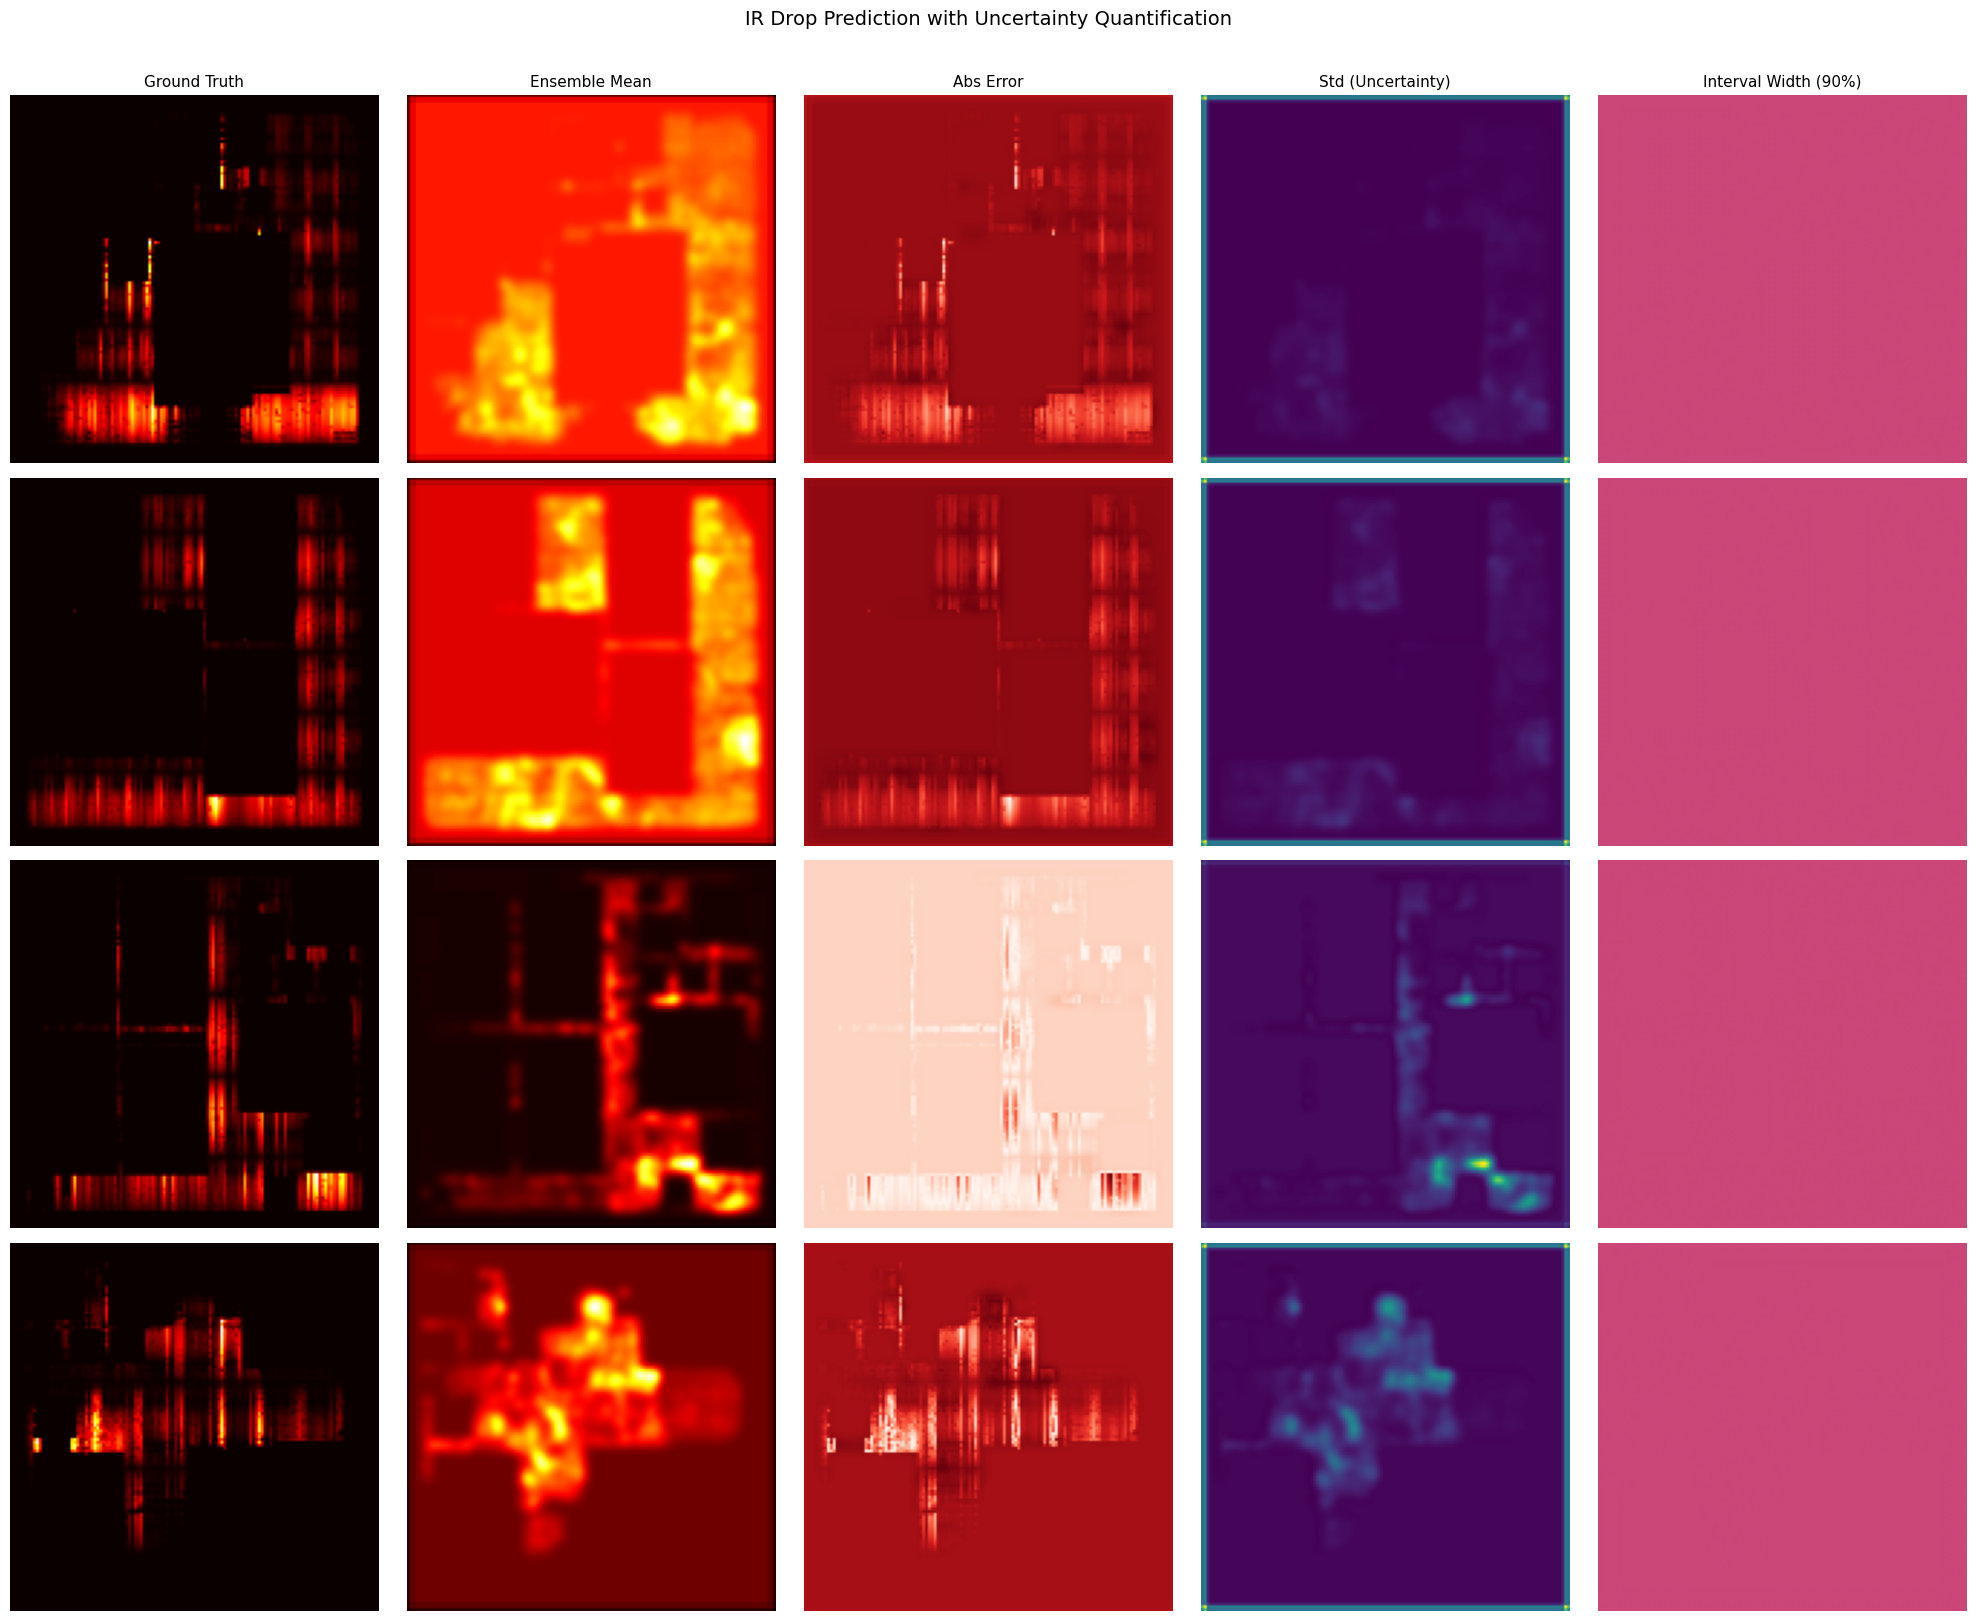

'./figures/prediction_samples.png'

In [35]:
plot_prediction_samples(
    ensemble_models, loaders['test'],
    conformal=scp, alpha=0.10, n_samples=4,
    save_path=os.path.join(cfg.fig_dir, 'prediction_samples.png'), device=device)


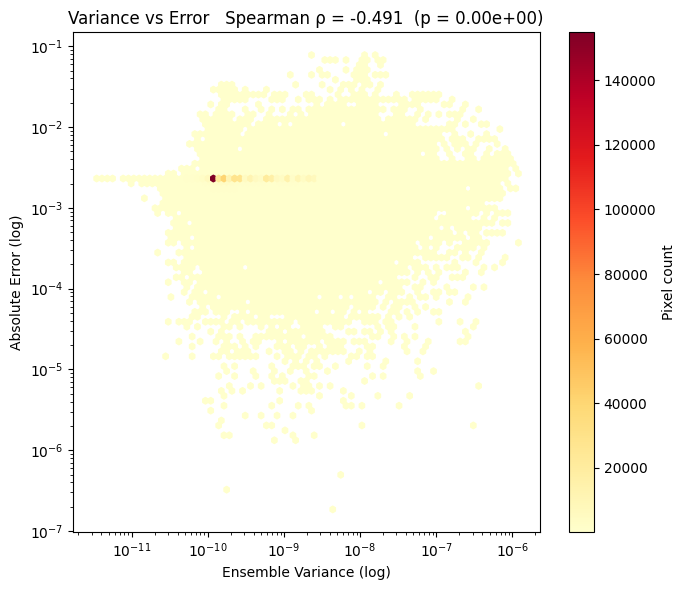

'./figures/variance_vs_error.png'

In [36]:
plot_variance_vs_error(
    ensemble_models, loaders['test'],
    save_path=os.path.join(cfg.fig_dir, 'variance_vs_error.png'), device=device)


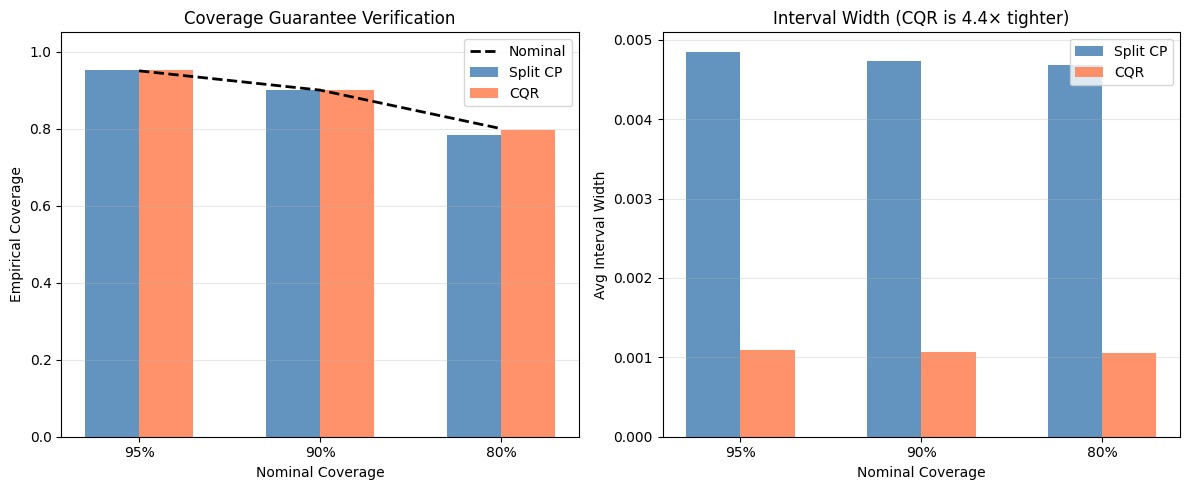

'./figures/coverage_comparison.png'

In [ ]:
plot_coverage_comparison(scp_results, cqr_results,save_path=os.path.join(cfg.fig_dir, 'coverage_comparison.png'))


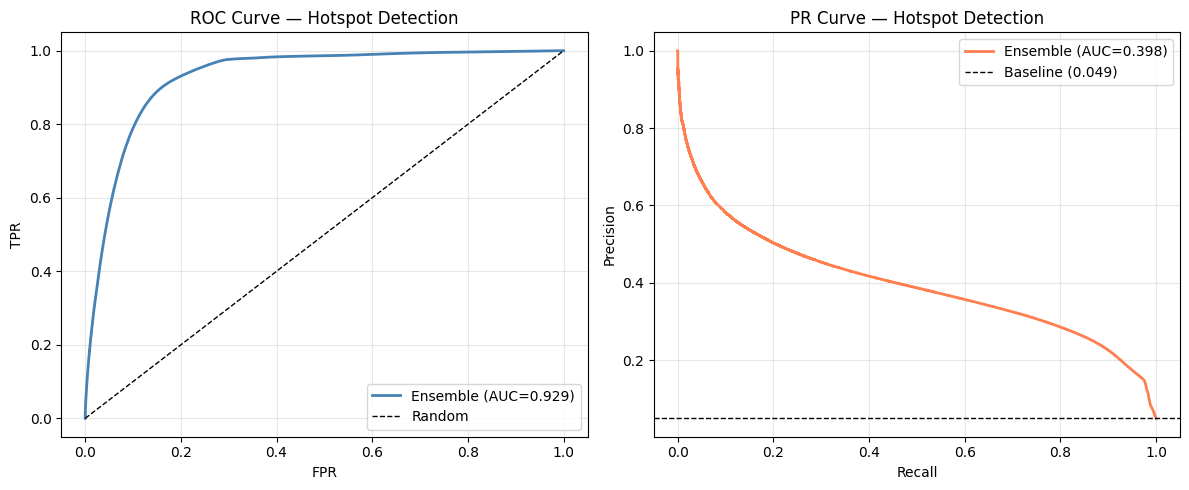

'./figures/roc_pr_curves.png'

In [ ]:
plot_roc_pr_curves(ensemble_models, loaders['test'], hotspot_thresh,save_path=os.path.join(cfg.fig_dir, 'roc_pr_curves.png'), device=device)


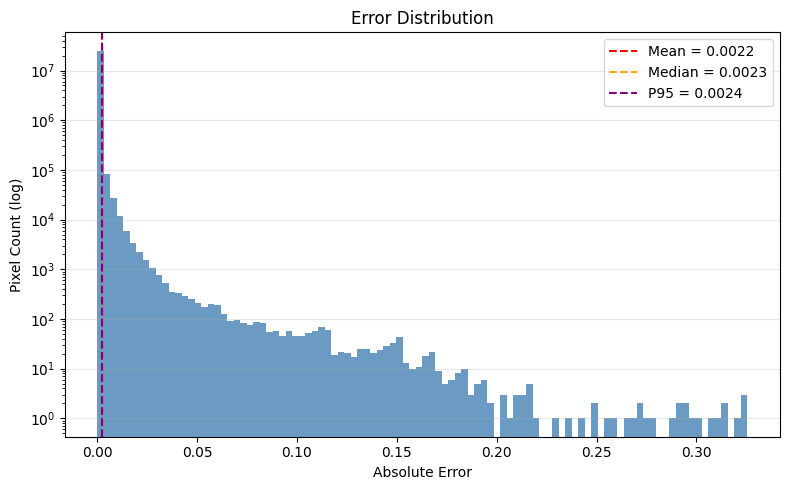

'./figures/error_distribution.png'

In [ ]:
plot_error_distribution(ensemble_models, loaders['test'],save_path=os.path.join(cfg.fig_dir, 'error_distribution.png'), device=device)
#We need this in the final report? What exactly does it show that the other figures don't? @sidharth

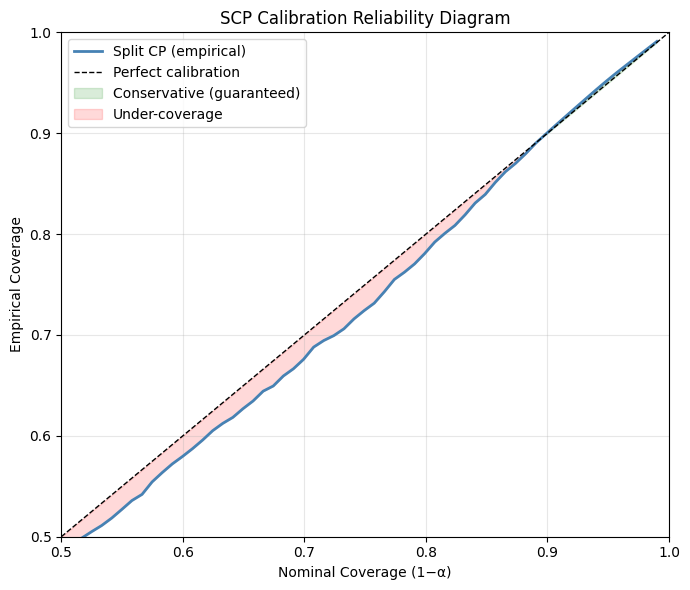

'./figures/calibration_curve.png'

In [40]:
plot_calibration_curve(
    scp, ensemble_models, loaders['test'],
    save_path=os.path.join(cfg.fig_dir, 'calibration_curve.png'), device=device)


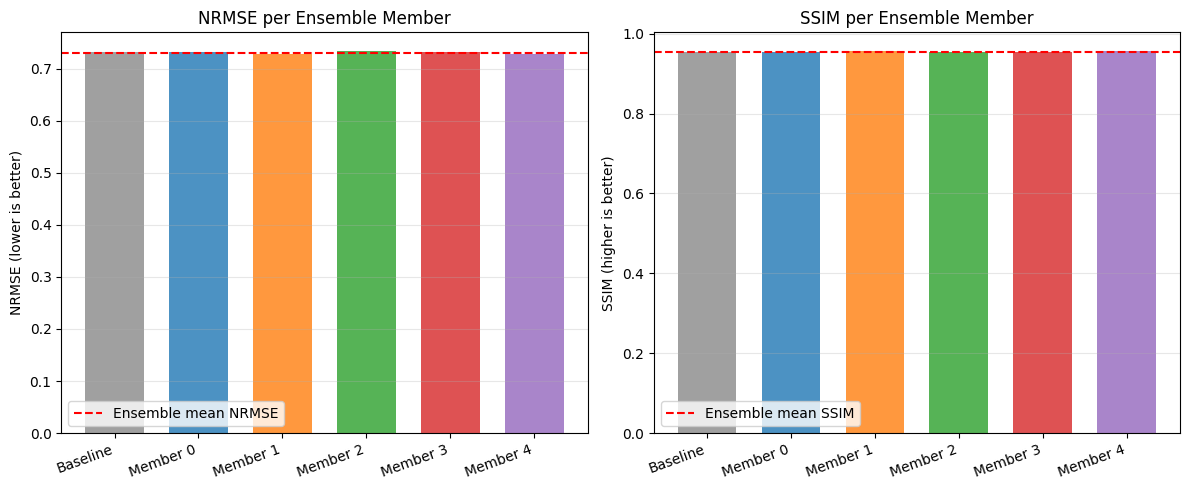

'./figures/ensemble_member_metrics.png'

In [ ]:
plot_ensemble_member_metrics(
    member_results, baseline_results,
    save_path=os.path.join(cfg.fig_dir, 'ensemble_member_metrics.png'))
#tihs is a weird plot. Do we need it? It just shows that the ensemble mean is prettty much the same @divin

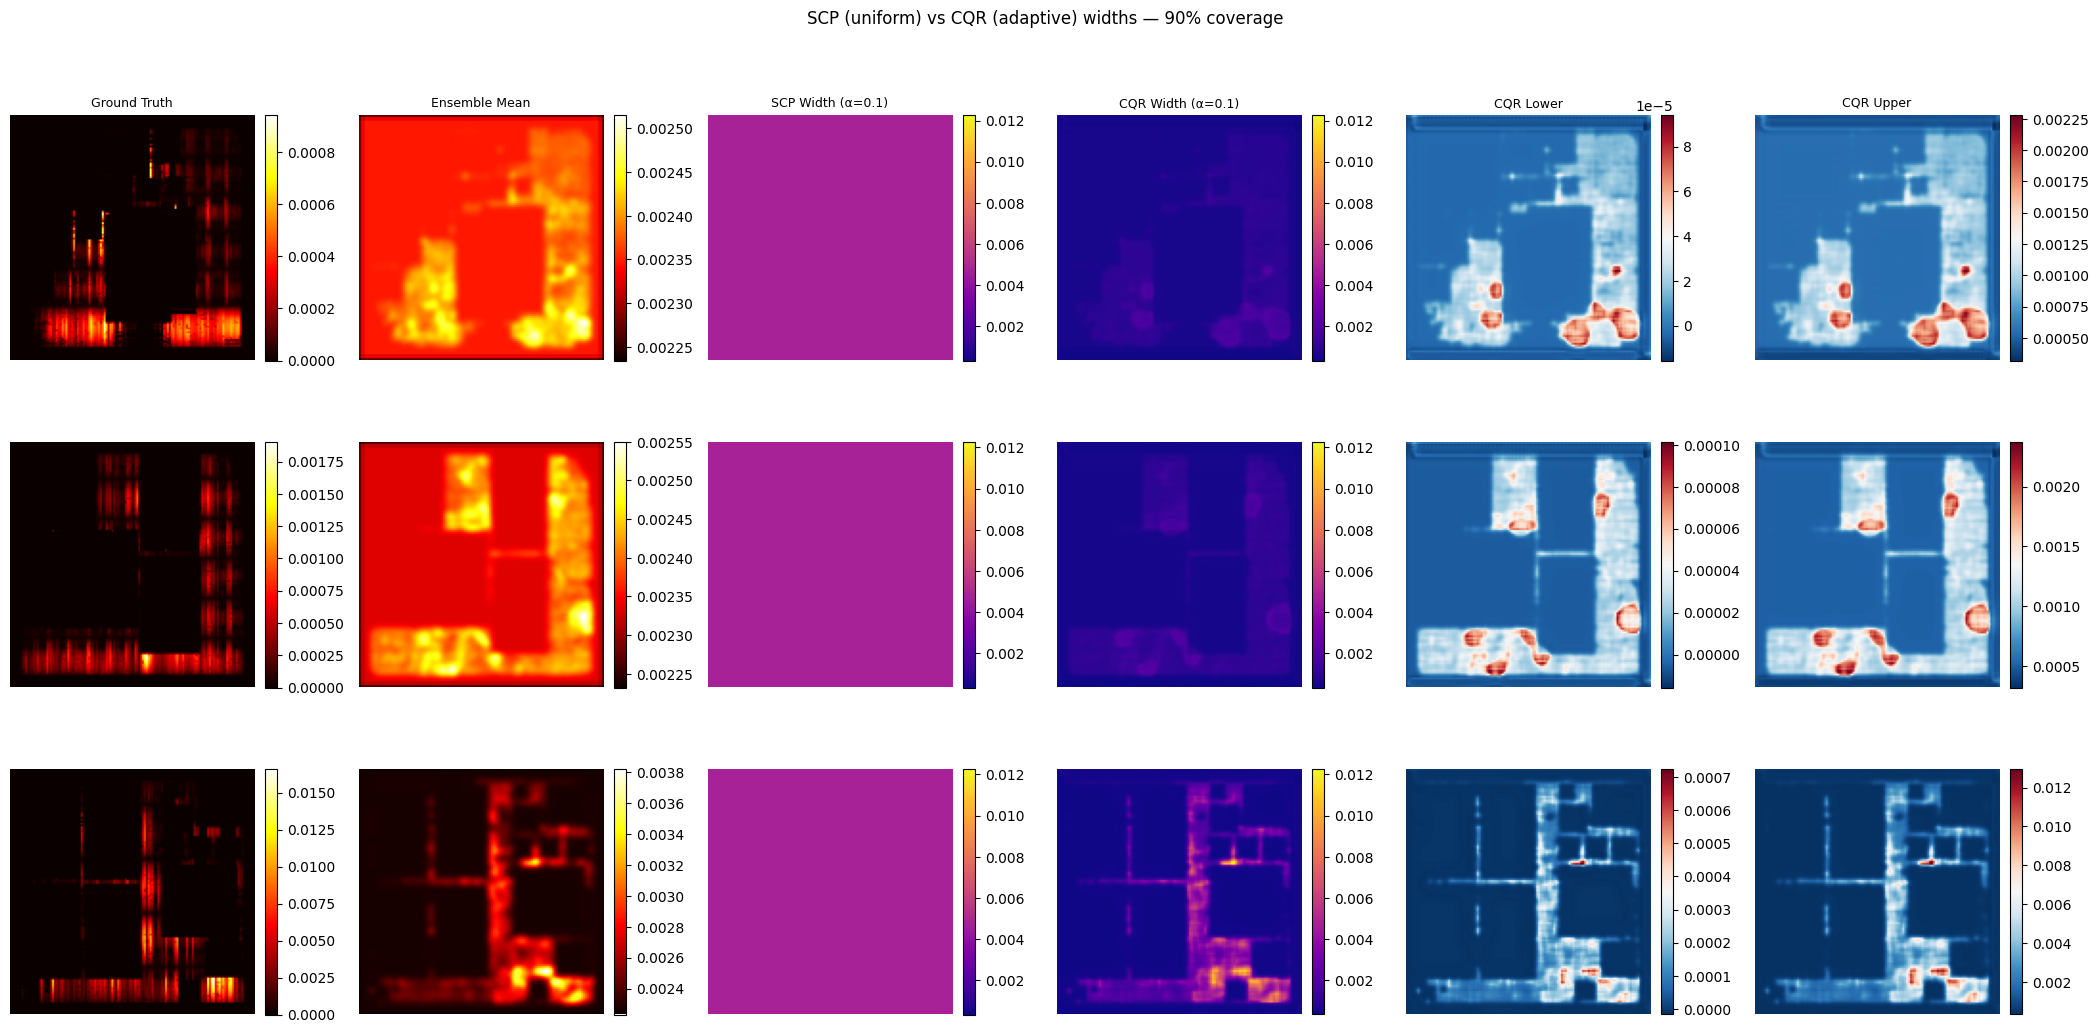

'./figures/adaptive_intervals.png'

In [ ]:
plot_adaptive_intervals(
    ensemble_models, qmodel, scp, cqr, loaders['test'],
    alpha=0.10, n_samples=3,
    save_path=os.path.join(cfg.fig_dir, 'adaptive_intervals.png'), device=device)
#use this in ppt

In [43]:
# this was the training code, but I commented it out because, I saved the models and then loaded them later to get results.
#
# loaders = build_dataloaders(cfg)
#
# # Stage 1
# baseline_model, baseline_hist = train_single_model(
#     cfg, loaders, model_id=0, seed=cfg.base_seed, device=device)
#
# thresh_path = os.path.join(cfg.save_dir, 'hotspot_thresh.npy')
# if not os.path.exists(thresh_path):
#     hotspot_thresh = compute_hotspot_threshold(loaders, cfg.hotspot_percentile)
#     np.save(thresh_path, np.array([hotspot_thresh]))
# else:
#     hotspot_thresh = float(np.load(thresh_path)[0])
#
# # Stage 2
# ensemble_models, ensemble_histories = train_ensemble(cfg, loaders, device=device)
# ens_results = evaluate_ensemble(ensemble_models, loaders['test'],
#                                  hotspot_thresh=hotspot_thresh, device=device)
#
# # Stage 3a
# scp = SplitConformalPredictor()
# scp.calibrate(ensemble_models, loaders['calib'], cfg.alpha_levels, device)
# scp_results = evaluate_conformal(ensemble_models, scp, loaders['test'],
#                                   cfg.alpha_levels, hotspot_thresh=hotspot_thresh, device=device)
#
# # Stage 3b
# qmodel = train_quantile_model(cfg, loaders, device=device)
# cqr = CQRPredictor()
# cqr.calibrate(qmodel, loaders['calib'], cfg.alpha_levels, device)
# cqr_results = evaluate_cqr(qmodel, cqr, loaders['test'],
#                              cfg.alpha_levels, hotspot_thresh=hotspot_thresh, device=device)